In [1]:
#julia version:1.11.6
include("Stability_Cavity.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall
using BSplineKit

In [2]:

function eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
    sigma = 0.72
    # Keep the existing -G convention used by the stability equations.
    cof = CRC_STA.Spatial_mode_BEK(F,-G,H,T,sigma,N_cheb,D,D2,R)
    A0_raw,A1_raw,A2_raw = CRC_STA.assemble_mat(cof :: CRC_STA.COF,D,D2,be,omega,R)
    A0,A1,A2 = CRC_STA.boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([A0,A1,A2])
    sigma_key = Symbol("\u03c3")
    kwargs = NamedTuple{(sigma_key, :neigs, :maxit, :tol)}((c, num, 500, 1e-10))
    eigval,eigvec = iar(nep; kwargs...)
    # iar ordering can change under tiny parameter changes; sort by shift distance.
    order = sortperm(abs.(eigval .- c))
    return eigval[order]
end

function eigsol_near(F,G,H,T,R,omega,be,N_cheb,D,D2; alpha_ref=0.384+0im, neigs=12)
    vals = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,real(alpha_ref),neigs)
    idx = argmin(abs.(vals .- alpha_ref))
    return vals[idx], vals
end


eigsol_near (generic function with 1 method)

In [3]:
function Cheb(N)
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    a = 2
    b = 0.6
    c = 0.5
    for i=1:N+1
        D[i,:]=D[i,:].* (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
    end
    for i=1:N+1
        x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
        if x[i] > 20
            x[i] = 20
        end
    end
    D2 = D^2;
    return D,D2,x
 end
 function interp(u0,v0,w0,T0,x,N)
    F = Base.zeros(N+1,1)
    G = Base.zeros(N+1,1)
    H = Base.zeros(N+1,1)
    T = Base.zeros(N+1,1)
    z = range(0,20,2000)
    itu = BSplineKit.interpolate(z, u0 , BSplineOrder(4))
    itv = BSplineKit.interpolate(z, v0 , BSplineOrder(4))
    itw = BSplineKit.interpolate(z, w0 , BSplineOrder(4))
    itt = BSplineKit.interpolate(z, T0 , BSplineOrder(4))
    for i = 1 : N + 1
        F[i,1] = itu(x[i])
        G[i,1] = itv(x[i])
        H[i,1] = itw(x[i])
        T[i,1] = itt(x[i])
    end
    return F,G,H,T
end

interp (generic function with 1 method)

In [12]:
Tw = 1.4
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)

([0.0, 0.010005002501250625, 0.02001000500250125, 0.030015007503751877, 0.0400200100050025, 0.05002501250625312, 0.060030015007503754, 0.07003501750875438, 0.080040020010005, 0.09004502251125562  …  19.909954977488745, 19.919959979989994, 19.929964982491246, 19.939969984992494, 19.949974987493746, 19.959979989995, 19.969984992496247, 19.9799899949975, 19.989994997498748, 20.0], [-3.353311679662549e-24, -6.0381241342281165e-5, -0.00023968363782430073, -0.0005351591036960846, -0.0009441151917855113, -0.0014638869090185804, -0.002091863917697847, -0.00282546284455992, -0.0036621539712388034, -0.004599434048174873  …  -0.8519237850097477, -0.8519237850490088, -0.8519237850835023, -0.8519237851132687, -0.8519237851383474, -0.8519237851587789, -0.8519237851746025, -0.8519237851858573, -0.851923785192582, -0.8519237851948149], [0.0, 0.006012100513884058, 0.011886167354761825, 0.017624294970694846, 0.023228553517791344, 0.02870100094483935, 0.03404367047998996, 0.03925858294513139, 0.044347734

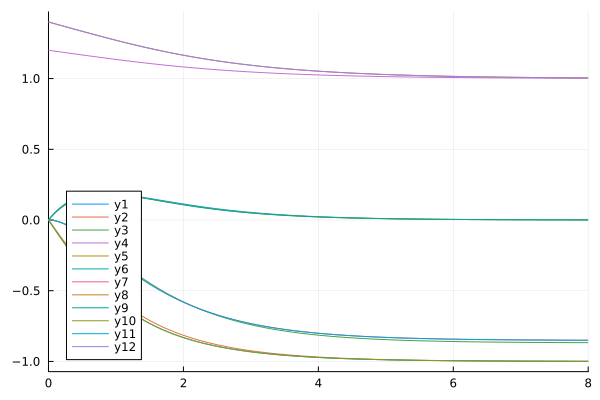

In [14]:
plot!(z,F,xlims=[0,8])
plot!(z,-G)
plot!(z,H)
plot!(z,T)

In [8]:
R = 285.365
omega = 0.0
be = 0.07759
Tw = 0.99
alpha_ref = 0.384 + 0im
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
c = 0.3
num = 3
D,D2,x = Cheb(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
val = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)

3-element Vector{ComplexF64}:
 0.22924447434145973 + 0.05387177759035162im
  0.3926561033246144 - 6.628218619544947e-5im
 0.24772160118535083 + 0.11086904898989572im

In [11]:
R_ini = 500
omega = 0.0
be_ini = 0.03
c_ini = 0.04
Tw = 1.03
num = 2
pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
bone = pyimport("Bone")
z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
N_cheb = 99
D,D2,x = Cheb(N_cheb)
F,G,H,T = interp(F,G,H,T,x,N_cheb)
cur(Tw,omega,R_ini,c_ini,be_ini,num)

In [10]:
function cur(Tw,omega,R_ini,c_ini,be_ini,num)
    be_step = -0.0005
    pushfirst!(PyVector(pyimport("sys")."path"), @__DIR__)
    bone = pyimport("Bone")
    z, H, F, G, T, dF, dG, dT, info = bone.get_baseflow(Tw)
    N_cheb = 99
    D,D2,x = Cheb(N_cheb)
    F,G,H,T = interp(F,G,H,T,x,N_cheb)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval_ori = eigsol(F,G,H,T,R_ini,omega,be_ini,N_cheb,D,D2,c_ini,num)
    open("output_eig.dat", "a") do io
        write(io,"be=$be_ini,eig=$eigval_ori\n")
    end
    eigval = sort(eigval_ori, by=real)
    if imag(eigval_ori[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval_ori[1]) > 0
        for be = be_ini : - be_step : 0.5
           sig_last1 = sign(imag(eigval[1]))
            sig_last2 = sign(imag(eigval[end]))
            eigval = eigsol(F,G,H,T,R_ini,omega,be,N_cheb,D,D2,c_ini,num)
            sig_now1 = sign(imag(eigval[1]))
            sig_now2 = sign(imag(eigval[end]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last1 * sig_now1 < 0 || sig_last2 * sig_now2 < 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 3
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval = eigsol(F,G,H,T,total[end,2],omega,be,N_cheb,D,D2,c,num)
        eigval_1 = eigsol(F,G,H,T,total[end,2],omega,be-0.001,N_cheb,D,D2,c,num)
        eigval_2 =  eigsol(F,G,H,T,total[end,2],omega,be+0.001,N_cheb,D,D2,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        num = 1
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0
                
                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700

                if total[end,3] == be

                    break

                end 
                
                eigval = eigsol(F,G,H,T,R,omega,be,N_cheb,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        eigval = eigsol(F,G,H,T,total[end,2] + 2,omega,be,N_cheb,D,D2,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += 0.0008
        filename = "ome=$(omega)_Tw=$(Tw).dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Tw=$(Tw)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 500 && size(total,1) > 30 
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 1 method)

In [ ]:
# 重新加载 Stability_Cavity.jl（修改后必须执行）
include("Stability_Cavity.jl")
println("✅ CRC_STA 模块已重载")

In [ ]:

# Isothermal neutral-point check.
# Benchmark: R=285.365, beta=0.07759, omega=0, alpha near 0.384.
R_test = 285.365
beta_test = 0.07759
omega_test = 0.0
alpha_ref = 0.384 + 0im
N_cheb = 199
D,D2,x = Cheb(N_cheb)

z_iso, H_iso, F_iso, G_iso, T_iso, dF_iso, dG_iso, dT_iso, info_iso = bone.get_baseflow(1.0)
F_iso, G_iso, H_iso, T_iso = interp(F_iso, G_iso, H_iso, T_iso, x, N_cheb)
println("Tw=1.0 baseflow ready, N_cheb=$N_cheb")
println("Hinf=$(H_iso[end]), T_wall=$(T_iso[1]), T_far=$(T_iso[end])")

alpha_iso, eigs_iso = eigsol_near(F_iso, G_iso, H_iso, T_iso,
                                  R_test, omega_test, beta_test,
                                  N_cheb, D, D2;
                                  alpha_ref=alpha_ref, neigs=16)
println("\nR=$R_test, beta=$beta_test, omega=$omega_test:")
println("selected alpha = $alpha_iso")
println("real(alpha) = $(real(alpha_iso))")
println("imag(alpha) = $(imag(alpha_iso))")
println("distance to alpha_ref = $(abs(alpha_iso-alpha_ref))")
println("all candidates near alpha_ref:")
for a in eigs_iso
    println("  $a")
end


In [ ]:

# Small-temperature neutral-point continuity check.
# Track the same eigenvalue branch by continuation from Tw=1.0.
R_test = 285.365
beta_test = 0.07759
omega_test = 0.0
N_cheb = 199
D,D2,x = Cheb(N_cheb)

function neutral_alpha_at_Tw(Tw, alpha_ref; neigs=20)
    zz, HH, FF, GG, TT, dFF, dGG, dTT, info = bone.get_baseflow(Tw)
    if !info["success"]
        return nothing, info
    end
    Fb, Gb, Hb, Tb = interp(FF, GG, HH, TT, x, N_cheb)
    alpha_tw, eigs_tw = eigsol_near(Fb, Gb, Hb, Tb,
                                    R_test, omega_test, beta_test,
                                    N_cheb, D, D2;
                                    alpha_ref=alpha_ref, neigs=neigs)
    return alpha_tw, info
end

alpha0, info0 = neutral_alpha_at_Tw(1.0, 0.384 + 0im; neigs=20)
println("Tw\t\treal(alpha)\timag(alpha)\t|delta from previous|")
println("1.0\t$(real(alpha0))\t$(imag(alpha0))\t0.0")

# Hot side continuation
alpha_ref = alpha0
for Tw in [1.001, 1.002, 1.005, 1.01, 1.02, 1.04]
    alpha_tw, info = neutral_alpha_at_Tw(Tw, alpha_ref; neigs=20)
    if alpha_tw === nothing
        println("$Tw\tbaseflow failed")
        continue
    end
    println("$Tw\t$(real(alpha_tw))\t$(imag(alpha_tw))\t$(abs(alpha_tw-alpha_ref))")
    alpha_ref = alpha_tw
end

# Cold side continuation
alpha_ref = alpha0
for Tw in [0.999, 0.998, 0.995, 0.99, 0.98, 0.96]
    alpha_tw, info = neutral_alpha_at_Tw(Tw, alpha_ref; neigs=20)
    if alpha_tw === nothing
        println("$Tw\tbaseflow failed")
        continue
    end
    println("$Tw\t$(real(alpha_tw))\t$(imag(alpha_tw))\t$(abs(alpha_tw-alpha_ref))")
    alpha_ref = alpha_tw
end


In [ ]:
plot(abs.(eigvec[:,1]))